In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/DrugInteraction_Project/final_dataset.csv')

print(f"Shape: {df.shape}")
print()
print(df.head(10).to_string())

Shape: (49505, 20)

          Drug_A       Drug_B     Level  label A_THERAPEUTIC_CLASS                                    A_ACTION_CLASS             A_CHEMICAL_CLASS A_HABIT_FORMING      A_alcohol_label    A_pregnancy_label      A_kidney_label       A_liver_label B_THERAPEUTIC_CLASS                                                  B_ACTION_CLASS                      B_CHEMICAL_CLASS B_HABIT_FORMING      B_alcohol_label    B_pregnancy_label       B_kidney_label        B_liver_label
0     Disulfiram     Abacavir     Minor      0           NEURO CNS                               Alcohol deaddiction         Carbamate Derivative              No                 SAFE  CONSULT YOUR DOCTOR             CAUTION             CAUTION     ANTI INFECTIVES  Nucleoside/nucleotide reverse transcriptase inhibitors (NRTIs)                   Nucleoside analogue              No              CAUTION  CONSULT YOUR DOCTOR   SAFE IF PRESCRIBED              CAUTION
1    Chloroquine   Paclitaxel  Moderate      1  

In [4]:
from sklearn.preprocessing import LabelEncoder

# Columns to encode
cat_cols = [
    'A_THERAPEUTIC_CLASS', 'A_ACTION_CLASS', 'A_CHEMICAL_CLASS',
    'A_HABIT_FORMING', 'A_alcohol_label', 'A_pregnancy_label',
    'A_kidney_label', 'A_liver_label',
    'B_THERAPEUTIC_CLASS', 'B_ACTION_CLASS', 'B_CHEMICAL_CLASS',
    'B_HABIT_FORMING', 'B_alcohol_label', 'B_pregnancy_label',
    'B_kidney_label', 'B_liver_label'
]

encoders = {}
df_encoded = df.copy()

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le

print("Encoding done.")
print()
print(df_encoded[cat_cols].head(3).to_string())

Encoding done.

   A_THERAPEUTIC_CLASS  A_ACTION_CLASS  A_CHEMICAL_CLASS  A_HABIT_FORMING  A_alcohol_label  A_pregnancy_label  A_kidney_label  A_liver_label  B_THERAPEUTIC_CLASS  B_ACTION_CLASS  B_CHEMICAL_CLASS  B_HABIT_FORMING  B_alcohol_label  B_pregnancy_label  B_kidney_label  B_liver_label
0                   10               9               115                0                2                  0               0              0                    1             193               285                0                0                  0               3              0
1                   11              41                10                0                1                  0               0              0                    3              48               438                0                2                  0               3              0
2                   10               9               115                0                2                  0               0              0    

In [5]:
from sklearn.model_selection import train_test_split

X = df_encoded[cat_cols]
y = df_encoded['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size : {X_train.shape}")
print(f"Test size  : {X_test.shape}")
print()
print("Train label distribution:")
print(y_train.value_counts())

Train size : (39604, 16)
Test size  : (9901, 16)

Train label distribution:
label
1    29770
2     7157
0     2677
Name: count, dtype: int64


In [7]:
# cell 4
!pip install xgboost -q

from xgboost import XGBClassifier
import numpy as np

# Calculate class weights to handle imbalance
class_counts = y_train.value_counts().sort_index()
total = len(y_train)
class_weights = {cls: total / (len(class_counts) * count)
                 for cls, count in class_counts.items()}

print("Class weights:", class_weights)

# Map weights to each training sample
sample_weights = y_train.map(class_weights).values

# Train model
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_test, y_test)],
    verbose=50
)

print("\nTraining complete.")

Class weights: {0: 4.931390860415888, 1: 0.44344418318217443, 2: 1.8445344883796748}
[0]	validation_0-mlogloss:1.07482


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:58:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-mlogloss:0.71486
[100]	validation_0-mlogloss:0.58883
[150]	validation_0-mlogloss:0.51219
[200]	validation_0-mlogloss:0.45755
[250]	validation_0-mlogloss:0.41496
[299]	validation_0-mlogloss:0.38359

Training complete.


=== Classification Report ===
              precision    recall  f1-score   support

       Minor       0.67      0.87      0.76       669
    Moderate       0.96      0.86      0.91      7443
       Major       0.66      0.89      0.76      1789

    accuracy                           0.86      9901
   macro avg       0.77      0.87      0.81      9901
weighted avg       0.89      0.86      0.87      9901

Weighted AUC-ROC: 0.9528


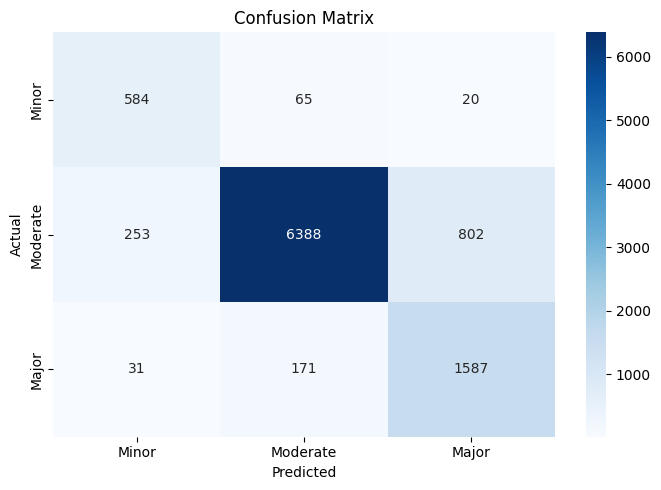

In [8]:
# cell 5
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred,
      target_names=['Minor', 'Moderate', 'Major']))

# AUC-ROC (one vs rest for multiclass)
auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
print(f"Weighted AUC-ROC: {auc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Minor', 'Moderate', 'Major'],
            yticklabels=['Minor', 'Moderate', 'Major'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DrugInteraction_Project/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

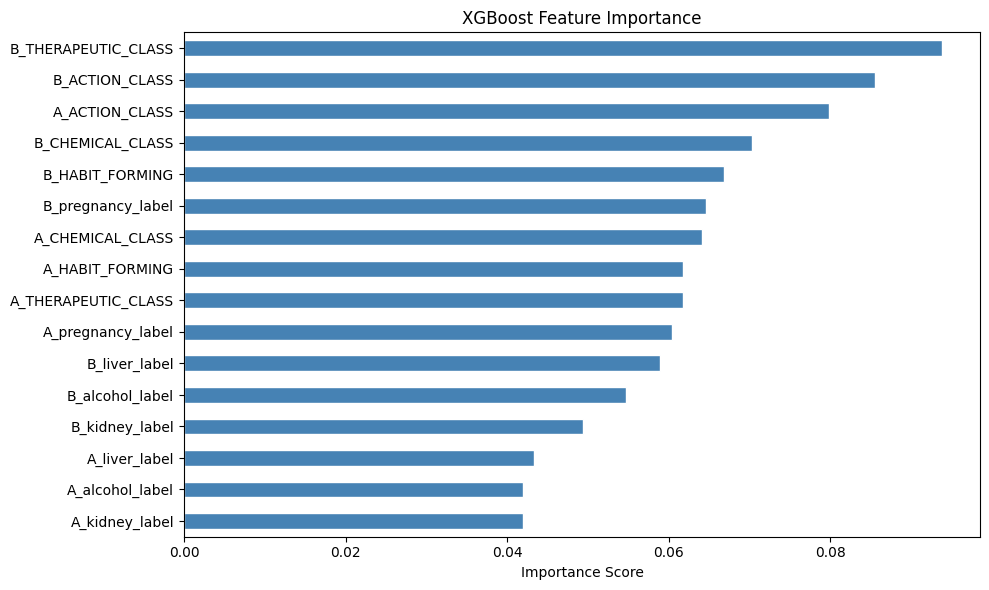


Top 5 most important features:
B_THERAPEUTIC_CLASS    0.093867
B_ACTION_CLASS         0.085591
A_ACTION_CLASS         0.079919
B_CHEMICAL_CLASS       0.070373
B_HABIT_FORMING        0.066916
dtype: float32


In [10]:
# cell 6
feat_importance = pd.Series(
    model.feature_importances_,
    index=cat_cols
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feat_importance.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DrugInteraction_Project/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 most important features:")
print(feat_importance.sort_values(ascending=False).head(5))

In [15]:
# cell 7
import joblib

save_path = '/content/drive/MyDrive/DrugInteraction_Project/'

# Save model
joblib.dump(model, save_path + 'xgb_model.pkl')

# Save encoders
joblib.dump(encoders, save_path + 'label_encoders.pkl')

print("Saved:")
print("  xgb_model.pkl")
print("  label_encoders.pkl")

Saved:
  xgb_model.pkl
  label_encoders.pkl


In [17]:
# cell 8
!pip install shap -q
import shap

# Use a sample of test data for speed
X_test_sample = X_test.sample(500, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_sample)

print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (500, 16, 3)


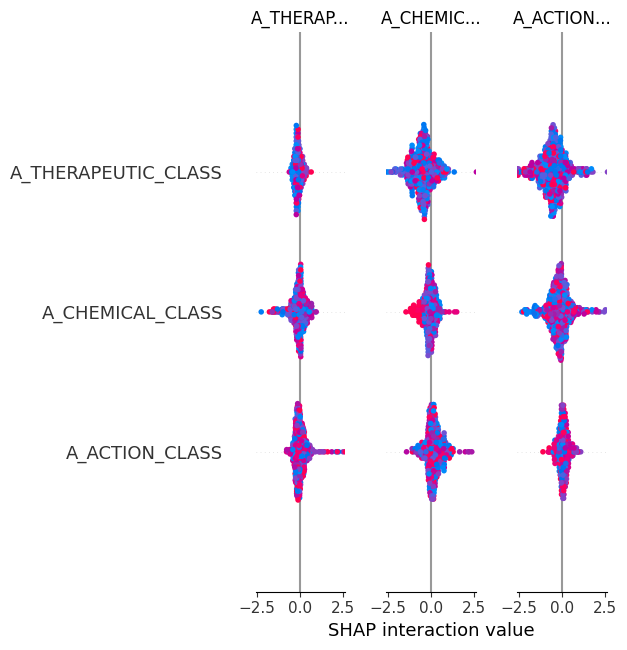

SHAP summary plot saved.


In [18]:
# cell 9
# Summary plot for all classes combined (mean absolute SHAP)
shap.summary_plot(
    shap_values,
    X_test_sample,
    class_names=['Minor', 'Moderate', 'Major'],
    show=False
)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DrugInteraction_Project/shap_summary.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("SHAP summary plot saved.")

In [19]:
# cell 10
# Pick one test sample and explain it
sample_idx = 0
single_sample = X_test_sample.iloc[[sample_idx]]
single_shap = shap_values[sample_idx]

# Get predicted class
pred_label = model.predict(single_sample)[0]
pred_prob = model.predict_proba(single_sample)[0]
label_map = {0: 'Minor', 1: 'Moderate', 2: 'Major'}

print(f"Drug A : {df.iloc[X_test_sample.index[sample_idx]]['Drug_A']}")
print(f"Drug B : {df.iloc[X_test_sample.index[sample_idx]]['Drug_B']}")
print(f"Actual : {label_map[y_test.iloc[X_test_sample.index.get_loc(X_test_sample.index[sample_idx])]]}")
print(f"Predicted : {label_map[pred_label]}")
print(f"Probabilities: Minor={pred_prob[0]:.2f}, Moderate={pred_prob[1]:.2f}, Major={pred_prob[2]:.2f}")
print()

# Top 3 SHAP features for predicted class
shap_for_pred_class = single_shap[:, pred_label]
feature_shap = pd.Series(shap_for_pred_class, index=cat_cols)
top_features = feature_shap.abs().sort_values(ascending=False).head(3)

print("Top 3 contributing features:")
for feat in top_features.index:
    raw_val = single_sample[feat].values[0]
    decoded_val = encoders[feat].inverse_transform([raw_val])[0]
    print(f"  {feat:30s} = {decoded_val:30s} | SHAP = {feature_shap[feat]:.4f}")

Drug A : Carboplatin
Drug B : Telbivudine
Actual : Moderate
Predicted : Moderate
Probabilities: Minor=0.09, Moderate=0.84, Major=0.07

Top 3 contributing features:
  B_CHEMICAL_CLASS               = Synthetic thymidine nucleoside analog | SHAP = 0.3822
  A_ACTION_CLASS                 = Platinum compounds-Anticancer  | SHAP = 0.2689
  B_liver_label                  = SAFE IF PRESCRIBED             | SHAP = 0.1652


In [20]:
# cell 11
import numpy as np

np.save(
    '/content/drive/MyDrive/DrugInteraction_Project/shap_values.npy',
    shap_values
)
print("Saved: shap_values.npy")

Saved: shap_values.npy
